In [ ]:
import ikpy
import ikpy.chain
import ikpy.inverse_kinematics
import numpy as np
from ikpy.utils import plot
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

from ipywidgets import *
%matplotlib widget

fig, ax = plot.init_3d_figure()

seal = ikpy.chain.Chain.from_urdf_file("seal.urdf",
                                       active_links_mask=[False, False, True, True, True, True, True, True, False])

ax.set_xlim3d([0, 0.3])
ax.set_ylim3d([0, 0.3])
ax.set_zlim3d([0, 0.3])
ax.legend()
x, y, z = seal.forward_kinematics([0] * (len(seal)))[:3,3]
z = 0
size = 0.5

def goto(x, y, z):
    ax.clear()
    ax.set_xlim3d([0, 0.3])
    ax.set_ylim3d([0,0.3])
    ax.set_zlim3d([0, 0.3])
    
    # frame_target = np.eye(4)
    # frame_target[:3, 3] = [x,y,z]

    ik = seal.inverse_kinematics(target_position=[x,y,z], max_iter=100)
    print(ik)
    seal.plot(ik, ax, target=[x,y,z])

    ax.legend()

interact(goto, 
         x=FloatSlider(min=x-size, max=x+size, value=x, step=0.01), 
         y=FloatSlider(min=y-size, max=y+size, value=y, step=0.01), 
         z=FloatSlider(min=z-size, max=z+size, value=z, step=0.01))



interactive(children=(FloatSlider(value=0.0, description='x', max=0.5, min=-0.5, step=0.01), FloatSlider(value…

<function __main__.goto(x, y, z, yaw, pitch, roll, coeff)>

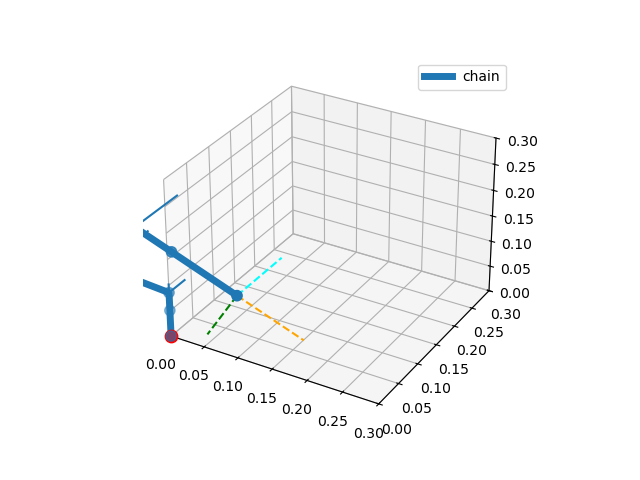

In [15]:
import ikpy
import ikpy.chain
import ikpy.inverse_kinematics
import numpy as np
from ikpy.utils import plot
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

from ipywidgets import *
%matplotlib widget

fig, ax = plot.init_3d_figure()

seal = ikpy.chain.Chain.from_urdf_file("seal.urdf",
                                       active_links_mask=[False, False, True, True, True, True, True, True, False])

ax.set_xlim3d([0, 0.3])
ax.set_ylim3d([0, 0.3])
ax.set_zlim3d([0, 0.3])
ax.legend()
x, y, z = seal.forward_kinematics([0] * (len(seal)))[:3,3]
z = 0
size = 0.5


def goto(x, y, z, yaw, pitch, roll, coeff):
    ax.clear()
    ax.set_xlim3d([0, 0.3])
    ax.set_ylim3d([0,0.3])
    ax.set_zlim3d([0, 0.3])
    ikpy.inverse_kinematics.ORIENTATION_COEFF = coeff/10
    
    # frame_target = np.eye(4)
    # frame_target[:3, 3] = [x,y,z]
    frame = np.eye(4)
    frame[:3,3] = [x, y, z]
    frame[:3, :3] = R.from_euler("ZYX", (yaw, pitch, roll),degrees=True).as_matrix()
    # print(frame)

    ik = ikpy.inverse_kinematics.inverse_kinematic_optimization(chain=seal, target_frame=frame, 
                                                                starting_nodes_angles=[0,0,0,0,0,0,0,0,0], max_iter=100,
                                                                orientation_mode="all", no_position=False)
    # print(ik)
    seal.plot(ik, ax, target=[x,y,z])

    ax.legend()

interact(goto, 
         x=FloatSlider(min=x-size, max=x+size, value=x, step=0.01), 
         y=FloatSlider(min=y-size, max=y+size, value=y, step=0.01), 
         z=FloatSlider(min=z-size, max=z+size, value=z, step=0.01),
         yaw=FloatSlider(min=-180, max=180, value=90, step=1),
         pitch=FloatSlider(min=-180, max=180, value=90, step=1),
         roll=FloatSlider(min=-180, max=180, value=90, step=1),
         coeff=FloatSlider(min=0, max=1, value=1, step=0.01),)

